# CLIP + SAM

In [1]:
import cv2
from segment_anything import build_sam, SamAutomaticMaskGenerator
from PIL import Image, ImageDraw
import clip
import torch
import numpy as np
import os

In [2]:
# 处理图像数据
image_path = "assets/test_hand_2.jpg"
im = cv2.imread(image_path)
w_h = 512
height, width, _ = im.shape
ratio = max(width, height) / w_h
new_width = int(width / ratio)
new_height = int(height / ratio)
im = cv2.resize(im, (new_width, new_height))

print(f"origin: {width},{height}")
print(f"resize: {new_width},{new_height}")
cv2.imwrite(image_path, im)

origin: 4032,3024
resize: 512,384


True

In [3]:
# Download the model weights to load them here
mask_generator = SamAutomaticMaskGenerator(build_sam(checkpoint="sam_vit_h_4b8939.pth"))

In [4]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
masks = mask_generator.generate(image)

In [5]:
masks[0]

{'segmentation': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 'area': 32970,
 'bbox': [151, 32, 344, 324],
 'predicted_iou': 1.010627269744873,
 'point_coords': [[232.0, 114.0]],
 'stability_score': 0.9590441584587097,
 'crop_box': [0, 0, 512, 384]}

In [6]:
def convert_box_xywh_to_xyxy(box):
    x1 = box[0]
    y1 = box[1]
    x2 = box[0] + box[2]
    y2 = box[1] + box[3]
    return [x1, y1, x2, y2]

In [7]:
def segment_image(image, segmentation_mask):
    image_array = np.array(image)
    segmented_image_array = np.zeros_like(image_array)

#     print(f"{image_array.shape}")
#     print(f"{len(segmentation_mask)},{len(segmentation_mask[0])}")
#     print(f"{image.size}")
    
    segmented_image_array[segmentation_mask] = image_array[segmentation_mask]
    segmented_image = Image.fromarray(segmented_image_array)
    black_image = Image.new("RGB", image.size, (0, 0, 0))
    transparency_mask = np.zeros_like(segmentation_mask, dtype=np.uint8)
    transparency_mask[segmentation_mask] = 255
    transparency_mask_image = Image.fromarray(transparency_mask, mode='L')
    black_image.paste(segmented_image, mask=transparency_mask_image)
    return black_image

In [8]:
# Cut out all masks
image = Image.open(image_path)
cropped_boxes = []

for mask in masks:
    cropped_boxes.append(segment_image(image, mask["segmentation"]).crop(convert_box_xywh_to_xyxy(mask["bbox"])))

In [9]:
# Load CLIP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)

In [10]:
@torch.no_grad()
def retriev2(elements, search_label: str) -> int:
    preprocessed_images = [preprocess(image).to(device) for image in elements]
    preprocessed_labels = [preprocess(label).to(device) for label in search_label]
    
    stacked_images = torch.stack(preprocessed_images)
    stacked_labels = torch.stack(preprocessed_labels)
    
    image_features = model.encode_image(stacked_images)
    label_features = model.encode_image(stacked_labels)

    image_features /= image_features.norm(dim=-1, keepdim=True)
    label_features /= label_features.norm(dim=-1, keepdim=True)
    label_features = torch.mean(label_features, dim=0, keepdim=True)
    
    print(f"image_shape:{image_features.shape}")
    print(f"text_shape:{label_features.shape}")
    
    probs = 100. * image_features @ label_features.T

    return probs[:, 0].softmax(dim=0)

In [11]:
def get_indices_of_values_above_threshold(values, threshold):
    return [i for i, v in enumerate(values) if v > threshold]

In [12]:
# 添加要检测的label
imgs_path = os.listdir("/workspaces/vm_robot/labels/hand")
labels = []
for path in imgs_path: 
    label = Image.open(os.path.join("/workspaces/vm_robot/labels/hand", path))
    labels.append(label)

image_shape:torch.Size([16, 512])
text_shape:torch.Size([1, 512])


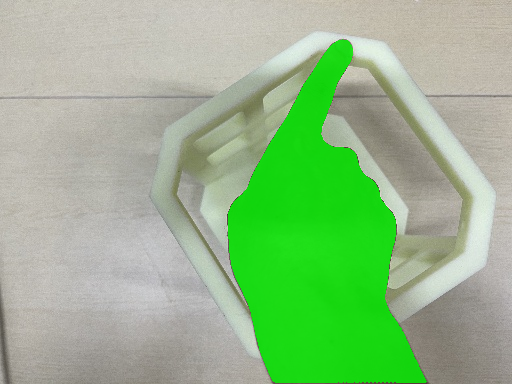

In [13]:
scores = retriev2(cropped_boxes, labels)
indices = get_indices_of_values_above_threshold(scores, 0.05)
# print(len(indices))

segmentation_masks = []

for seg_idx in indices:
    segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
    segmentation_masks.append(segmentation_mask_image)

original_image = Image.open(image_path)
overlay_image = Image.new('RGBA', image.size, (0, 0, 0, 0))
overlay_color = (0, 255, 0, 200)

draw = ImageDraw.Draw(overlay_image)
for segmentation_mask_image in segmentation_masks:
    draw.bitmap((0, 0), segmentation_mask_image, fill=overlay_color)

result_image = Image.alpha_composite(original_image.convert('RGBA'), overlay_image)
result_image